<a href="https://colab.research.google.com/github/Tar-ive/dl_basics/blob/main/CNN_PyTorch_CIFAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Adding Convolution Layers

In [11]:
import torch
import torch.nn as nn
import torchvision
import torch.optim as optim
import torchvision.transforms as transforms

In [12]:
# Load CIFAR Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))]
)

train_dataset = torchvision.datasets.CIFAR10(root= "./data", train = True, download = True, transform = transform)
test_dataset = torchvision.datasets.CIFAR10(root = "./data", train = False, download = True, transform = transform)
train_loader= torch.utils.data.DataLoader(train_dataset, batch_size = 64, shuffle=True)
test_loader= torch.utils.data.DataLoader(test_dataset, batch_size = 64, shuffle=True)

In [13]:
train_dataset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )

In [14]:
#Define the CNN Model
class CNNModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 32, kernel_size =3, stride = 1, padding = 1) # Output: 32x32x32
    self.conv2 = nn.Conv2d(32, 64, kernel_size = 3, stride = 1, padding = 1) # Output : 64x32x32
    self.pool = nn.MaxPool2d(kernel_size=2, stride = 2) # 64x16x16
    self.fc1 = nn.Linear(64*16*16, 128)
    self.fc2= nn.Linear(128,10)# becuase needs to be 10 classes
    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.relu(self.conv1(x))
    x = self.pool(self.relu(self.conv2(x)))
    x = x.view(x.size(0),-1) # Flattening
    x = self.relu(self.fc1(x))
    x = self.fc2(x)
    return x

In [15]:
# Initialize Model,Loss function and optimizer
model = CNNModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#Training Loop
epochs = 10
for epoch in range(epochs):
  for images, labels in train_loader:
    #Forward pass
    outputs = model(images)
    loss = criterion(outputs, labels)

    #Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  print(f"Epochs: {epoch+1}/ {epochs},  Loss = {loss.item():.4f} ")




Epochs: 1/ 10,  Loss = 0.6889 
Epochs: 2/ 10,  Loss = 0.7502 
Epochs: 3/ 10,  Loss = 0.5206 
Epochs: 4/ 10,  Loss = 0.6852 
Epochs: 5/ 10,  Loss = 0.2668 
Epochs: 6/ 10,  Loss = 0.5554 
Epochs: 7/ 10,  Loss = 0.0745 
Epochs: 8/ 10,  Loss = 0.0034 
Epochs: 9/ 10,  Loss = 0.1147 
Epochs: 10/ 10,  Loss = 0.0589 


In [16]:
# Evaluate on the test set
correct = 0
total = 0
with torch.no_grad():
  for images,labels in test_loader:
    outputs= model(images)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted==labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f} ")


Test Accuracy: 68.02 


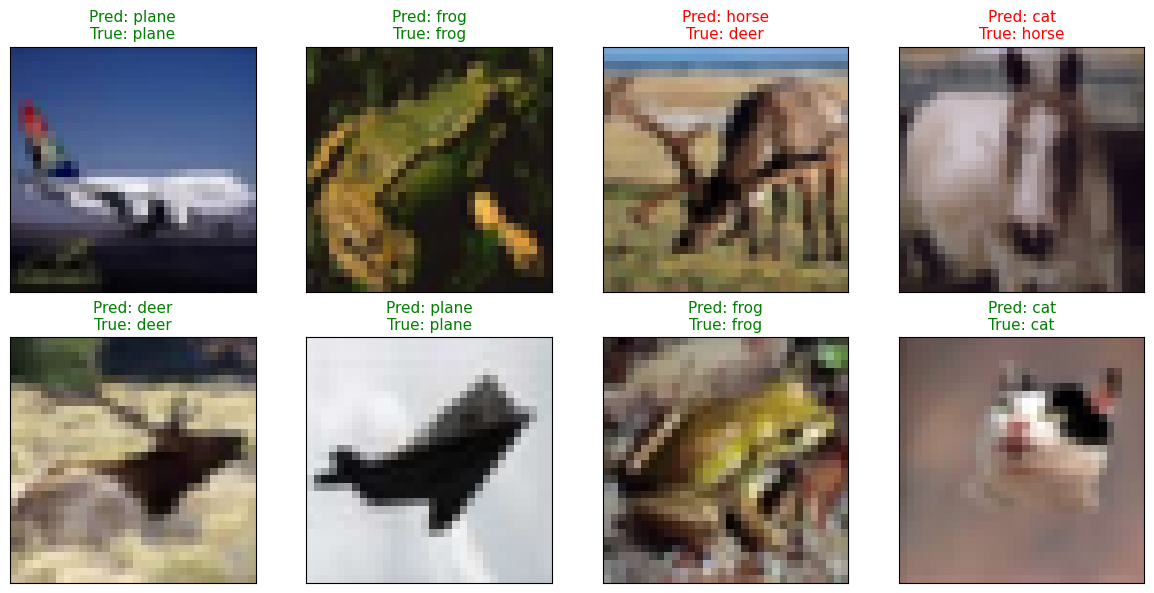

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import torchvision.transforms as transforms

# CIFAR-10 class labels
classes = (
    "plane",
    "car",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)

# Grab a batch of 8 images from the test loader
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Set model to evaluation mode
model.eval()
with torch.no_grad():
  outputs = model(images)
  _, predicted = torch.max(outputs, 1)


# Function to un-normalize and convert tensor to numpy image
def imshow(img):
  img = img / 2 + 0.5  # Unnormalize from [-1, 1] to [0, 1]
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))


# Plot the images with predictions
fig = plt.figure(figsize=(12, 6))
for idx in range(8):
  ax = fig.add_subplot(2, 4, idx + 1, xticks=[], yticks=[])
  imshow(images[idx])

  pred_label = classes[predicted[idx]]
  true_label = classes[labels[idx]]

  # Color title green if correct, red if incorrect
  color = "green" if pred_label == true_label else "red"
  ax.set_title(
      f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=11
  )

plt.tight_layout()
plt.show()